#  Telecom Customer Churn Analysis
### End-to-End Data Analysis & Machine Learning Project

---

##  Problem Statement
> A telecom company is losing customers every month. The goal of this project is to **identify why customers churn**, **which customers are at risk**, and **build a machine learning model** to predict churn.

##  Project Goals
1. Perform EDA to find patterns in customer behavior
2. Identify top factors driving churn
3. Build and compare 4 ML models
4. Provide actionable business recommendations

---

## 1.  Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
print(' All libraries imported successfully!')

 All libraries imported successfully!


## 2.  Load & Understand the Data

In [24]:
df = pd.read_csv('telecom_customer_churn.csv')
df.columns = df.columns.str.strip()
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset Shape: 7043 rows × 38 columns


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,...,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,NaN,NaN
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,...,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,NaN,NaN
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,...,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,NaN,NaN


### 2.1 Data Dictionary

In [25]:
dict_df = pd.read_csv('telecom_data_dictionary.csv', encoding='latin1')
dict_df.columns = dict_df.columns.str.strip()
print('Data Dictionary:')
dict_df

Data Dictionary:


,Table,Field,Description
0,Customer Churn,CustomerID,A unique ID that identifies each customer
1,Customer Churn,Gender,"The customers gender: Male, Female"
2,Customer Churn,Age,"The customers current age, in years, at the t..."
3,Customer Churn,Married,"Indicates if the customer is married: Yes, No"
4,Customer Churn,Number of Dependents,Indicates the number of dependents that live w...
5,Customer Churn,City,The city of the customers primary residence i...
6,Customer Churn,Zip Code,The zip code of the customers primary residence
7,Customer Churn,Latitude,The latitude of the customers primary residence
8,Customer Churn,Longitude,The longitude of the customers primary residence
9,Customer Churn,Number of Referrals,Indicates the number of times the customer has...


### 2.2 Data Overview

In [26]:
print(f'Shape: {df.shape}')
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Statistical Summary ---')
df.describe()

Shape: (7043, 38)

--- Data Types ---
Customer ID                           object
Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Supp

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [27]:
print('--- Missing Values ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print('\n--- Unique Values Per Column ---')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')

--- Missing Values ---
                                   Missing Count  Missing %
Offer                                       3877      55.05
Avg Monthly Long Distance Charges            682       9.68
Multiple Lines                               682       9.68
Internet Type                               1526      21.67
Avg Monthly GB Download                     1526      21.67
Online Security                             1526      21.67
Online Backup                               1526      21.67
Device Protection Plan                      1526      21.67
Premium Tech Support                        1526      21.67
Streaming TV                                1526      21.67
Streaming Movies                            1526      21.67
Streaming Music                             1526      21.67
Unlimited Data                              1526      21.67
Churn Category                              5174      73.46
Churn Reason                                5174      73.46

--- Unique Value

In [28]:
# Drop rows only where KEY columns are missing
# Note: Churn Category & Churn Reason are NULL for non-churned customers - that is normal!
key_cols = ['Customer Status', 'Gender', 'Age', 'Contract',
            'Tenure in Months', 'Monthly Charge', 'Total Charges']
before = len(df)
df.dropna(subset=key_cols, inplace=True)
print(f'Rows before: {before} | After: {len(df)} | Dropped: {before - len(df)}')
print('\nCustomer Status distribution:')
print(df['Customer Status'].value_counts())

Rows before: 7043 | After: 7043 | Dropped: 0

Customer Status distribution:
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


---
## 3.  Exploratory Data Analysis (EDA)
---

### 3.1 Churn Distribution

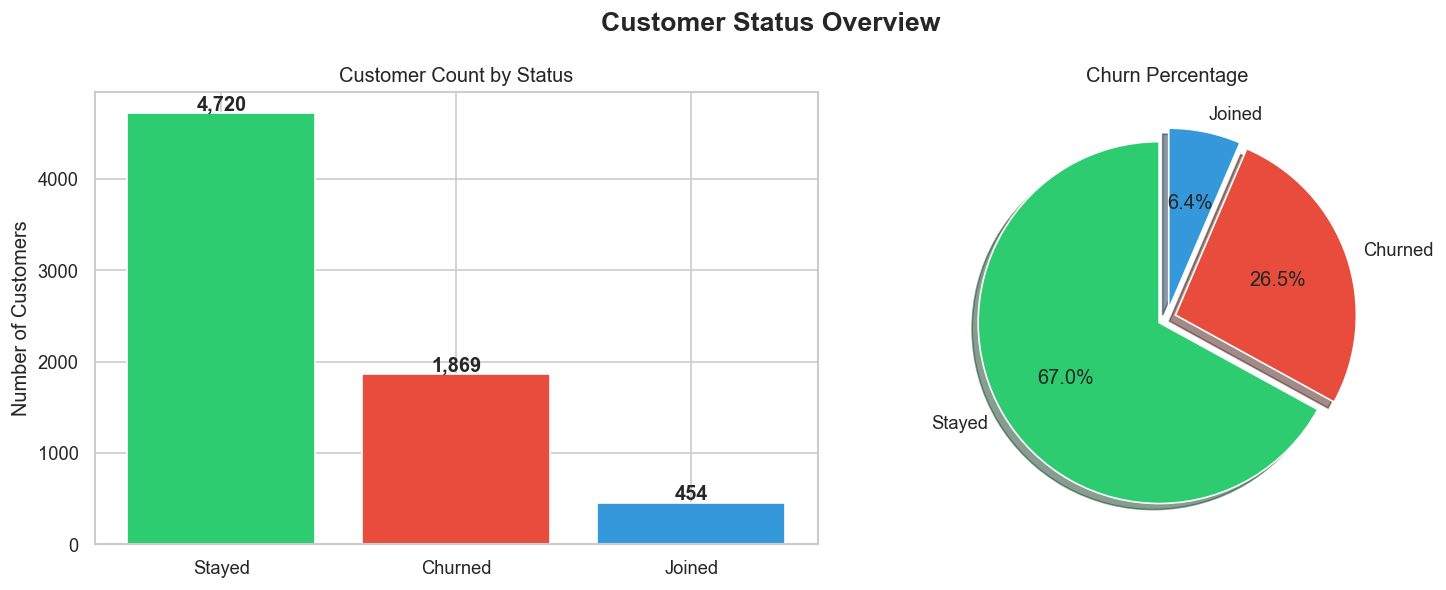


 Overall Churn Rate: 26.5%


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Customer Status Overview', fontsize=16, fontweight='bold')
status_counts = df['Customer Status'].value_counts()
bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Customer Count by Status')
axes[0].set_ylabel('Number of Customers')
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#3498db'],
            shadow=True, startangle=90, explode=[0.05]*len(status_counts))
axes[1].set_title('Churn Percentage')
plt.tight_layout()
plt.show()
churn_rate = (df['Customer Status'] == 'Churned').sum() / len(df) * 100
print(f'\n Overall Churn Rate: {churn_rate:.1f}%')

### 3.2 Why Are Customers Leaving? — Churn Reasons

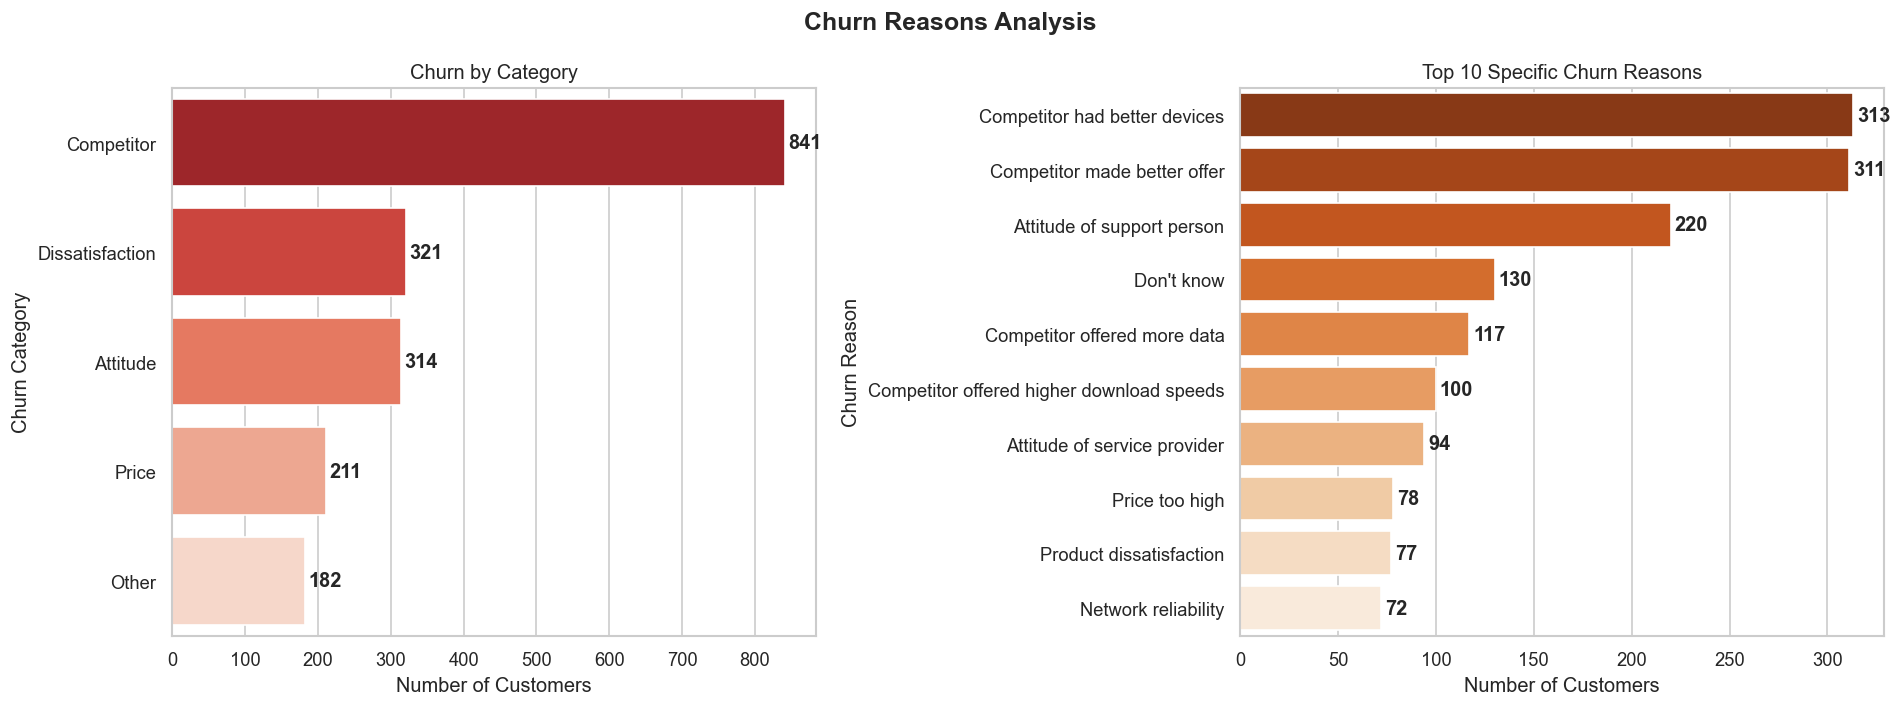

In [30]:
churned_df = df[df['Customer Status'] == 'Churned']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn Reasons Analysis', fontsize=15, fontweight='bold')
cat_counts = churned_df['Churn Category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Churn by Category')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')
reason_counts = churned_df['Churn Reason'].value_counts().head(10)
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Specific Churn Reasons')
axes[1].set_xlabel('Number of Customers')
for i, v in enumerate(reason_counts.values):
    axes[1].text(v + 2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Contract Type vs Churn

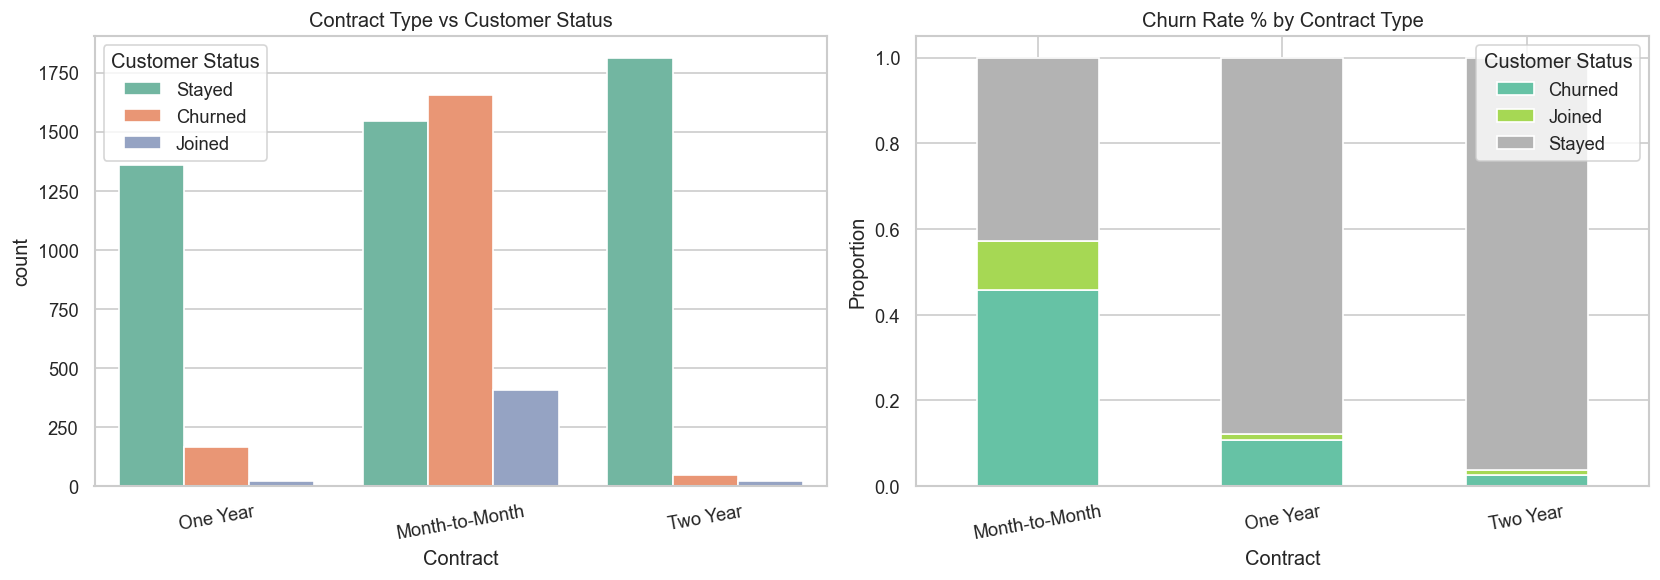

 Churn rate by contract type:
Contract
Month-to-Month    45.8
One Year          10.7
Two Year           2.5


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Contract', hue='Customer Status', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Contract Type vs Customer Status')
axes[0].tick_params(axis='x', rotation=10)
grouped = df.groupby('Contract')['Customer Status'].value_counts(normalize=True).unstack()
grouped.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1], edgecolor='white')
axes[1].set_title('Churn Rate % by Contract Type')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()
churn_by_contract = df[df['Customer Status']=='Churned'].groupby('Contract').size() / df.groupby('Contract').size() * 100
print(' Churn rate by contract type:')
print(churn_by_contract.round(1).to_string())

### 3.4 Tenure vs Churn

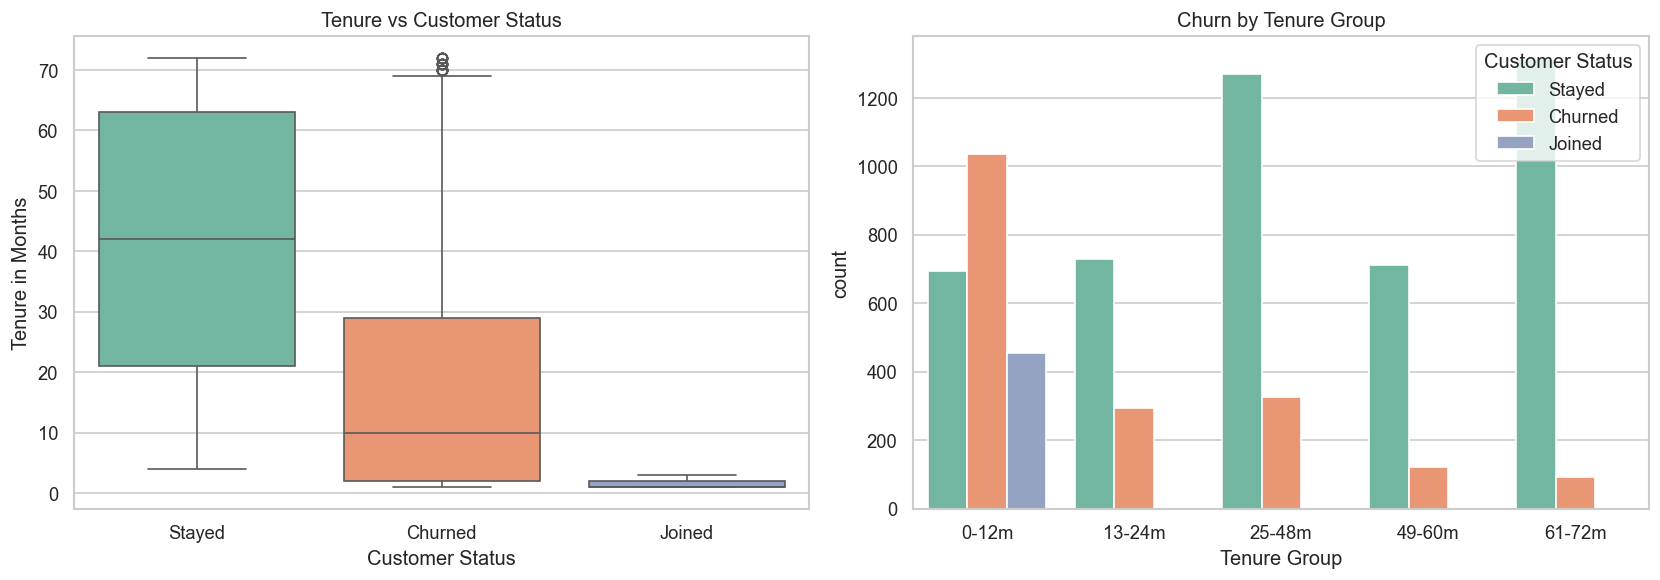

 Average tenure by status:
Customer Status
Churned    18.0
Joined      1.7
Stayed     41.0


In [48]:
df['Tenure in Months'] = pd.to_numeric(df['Tenure in Months'], errors='coerce')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Customer Status', y='Tenure in Months', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tenure vs Customer Status')
df['Tenure Group'] = pd.cut(df['Tenure in Months'],
    bins=[0, 12, 24, 48, 60, 72], labels=['0-12m', '13-24m', '25-48m', '49-60m', '61-72m'])
sns.countplot(x='Tenure Group', hue='Customer Status', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Tenure Group')
plt.tight_layout()
plt.show()
print(' Average tenure by status:')
print(df.groupby('Customer Status')['Tenure in Months'].mean().round(1).to_string())

### 3.5 Monthly & Total Charges vs Churn

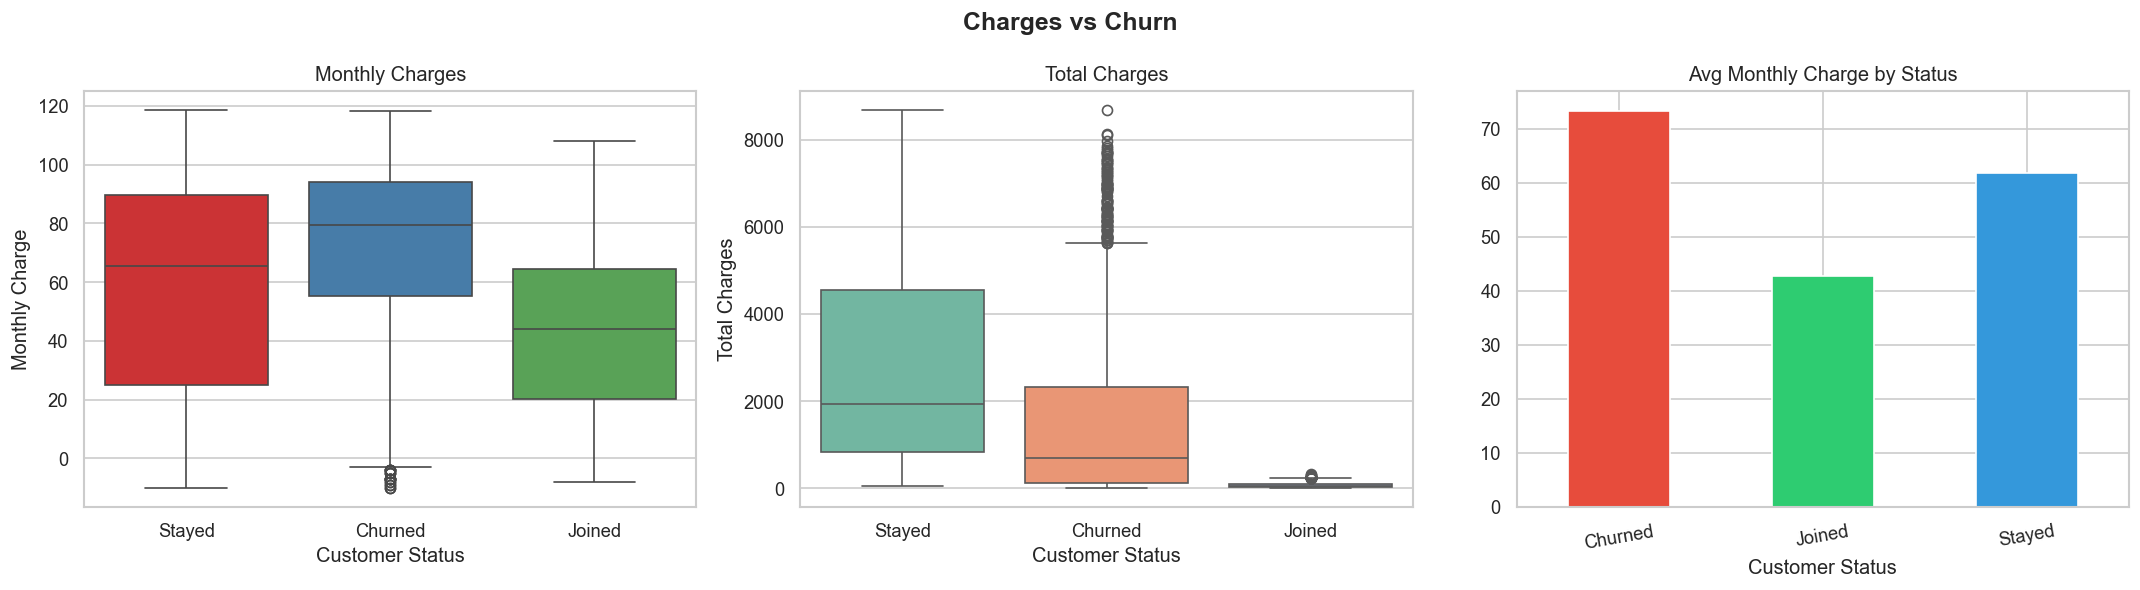

In [33]:
df['Monthly Charge'] = pd.to_numeric(df['Monthly Charge'], errors='coerce')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Charges vs Churn', fontsize=15, fontweight='bold')
sns.boxplot(x='Customer Status', y='Monthly Charge', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Monthly Charges')
sns.boxplot(x='Customer Status', y='Total Charges', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Total Charges')
df.groupby('Customer Status')['Monthly Charge'].mean().plot(
    kind='bar', color=['#e74c3c', '#2ecc71', '#3498db'], ax=axes[2], edgecolor='white')
axes[2].set_title('Avg Monthly Charge by Status')
axes[2].tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

### 3.6 Gender, Age, Partner & Dependents vs Churn

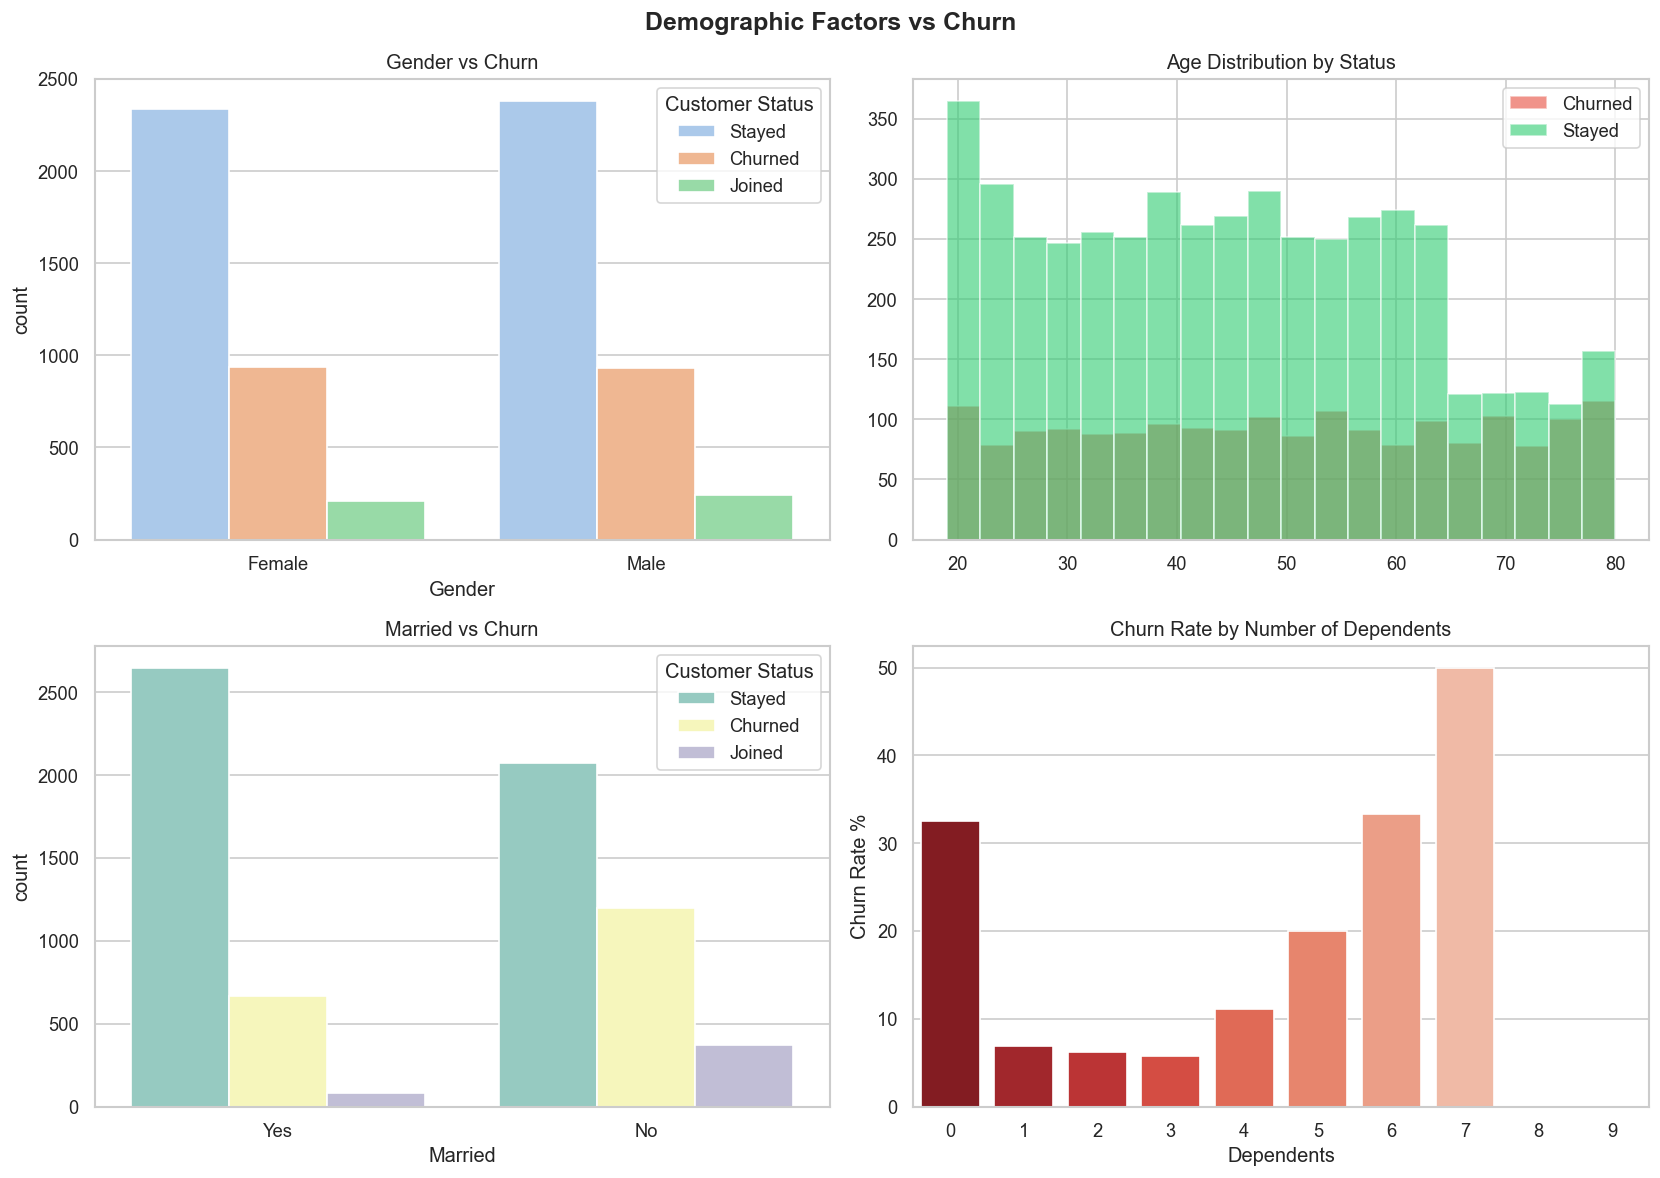

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demographic Factors vs Churn', fontsize=15, fontweight='bold')
sns.countplot(x='Gender', hue='Customer Status', data=df, palette='pastel', ax=axes[0][0])
axes[0][0].set_title('Gender vs Churn')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
for status, color in zip(['Churned', 'Stayed'], ['#e74c3c', '#2ecc71']):
    axes[0][1].hist(df[df['Customer Status']==status]['Age'].dropna(),
                    bins=20, alpha=0.6, label=status, color=color)
axes[0][1].set_title('Age Distribution by Status')
axes[0][1].legend()
sns.countplot(x='Married', hue='Customer Status', data=df, palette='Set3', ax=axes[1][0])
axes[1][0].set_title('Married vs Churn')
df['Number of Dependents'] = pd.to_numeric(df['Number of Dependents'], errors='coerce')
dep_churn = df.groupby('Number of Dependents')['Customer Status'].apply(
    lambda x: (x=='Churned').sum() / len(x) * 100).reset_index()
dep_churn.columns = ['Dependents', 'Churn Rate %']
sns.barplot(x='Dependents', y='Churn Rate %', data=dep_churn, palette='Reds_r', ax=axes[1][1])
axes[1][1].set_title('Churn Rate by Number of Dependents')
plt.tight_layout()
plt.show()

### 3.7 Internet Service vs Churn

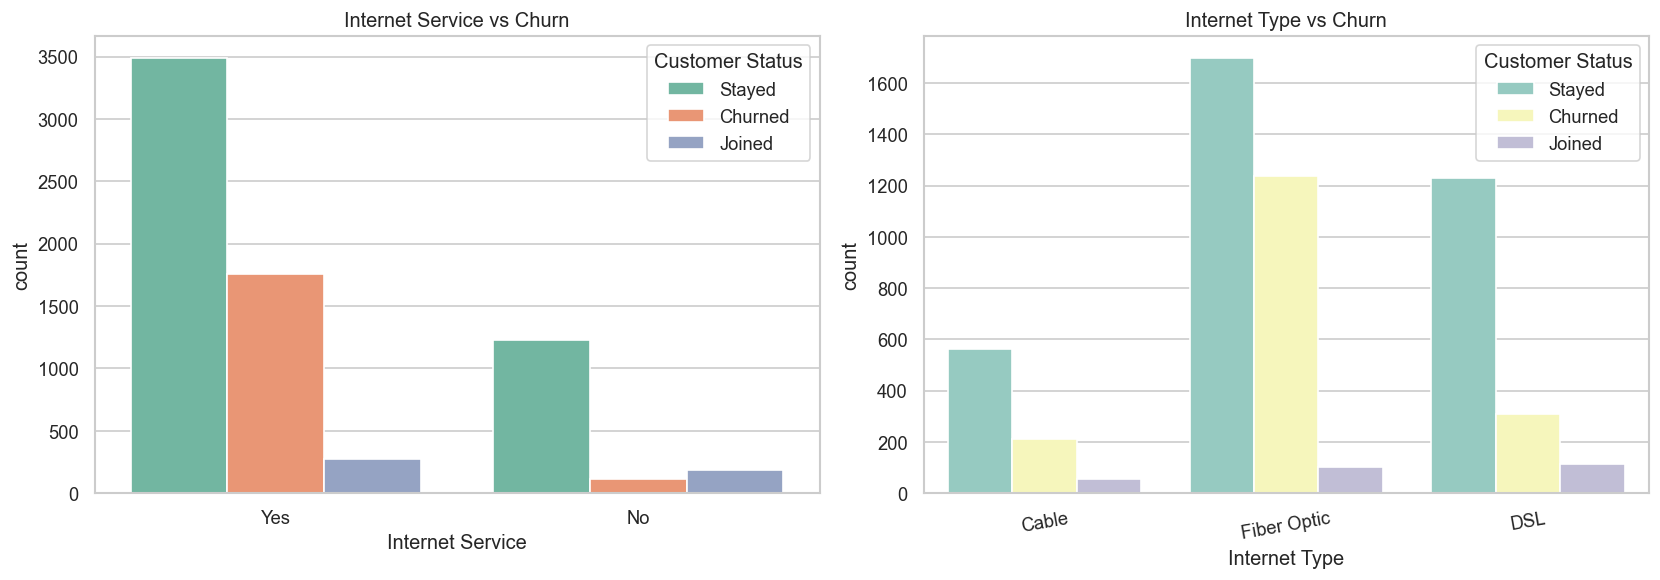

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Internet Service', hue='Customer Status', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Internet Service vs Churn')
sns.countplot(x='Internet Type', hue='Customer Status', data=df, palette='Set3', ax=axes[1])
axes[1].set_title('Internet Type vs Churn')
axes[1].tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

### 3.8 Feature Correlation Heatmap

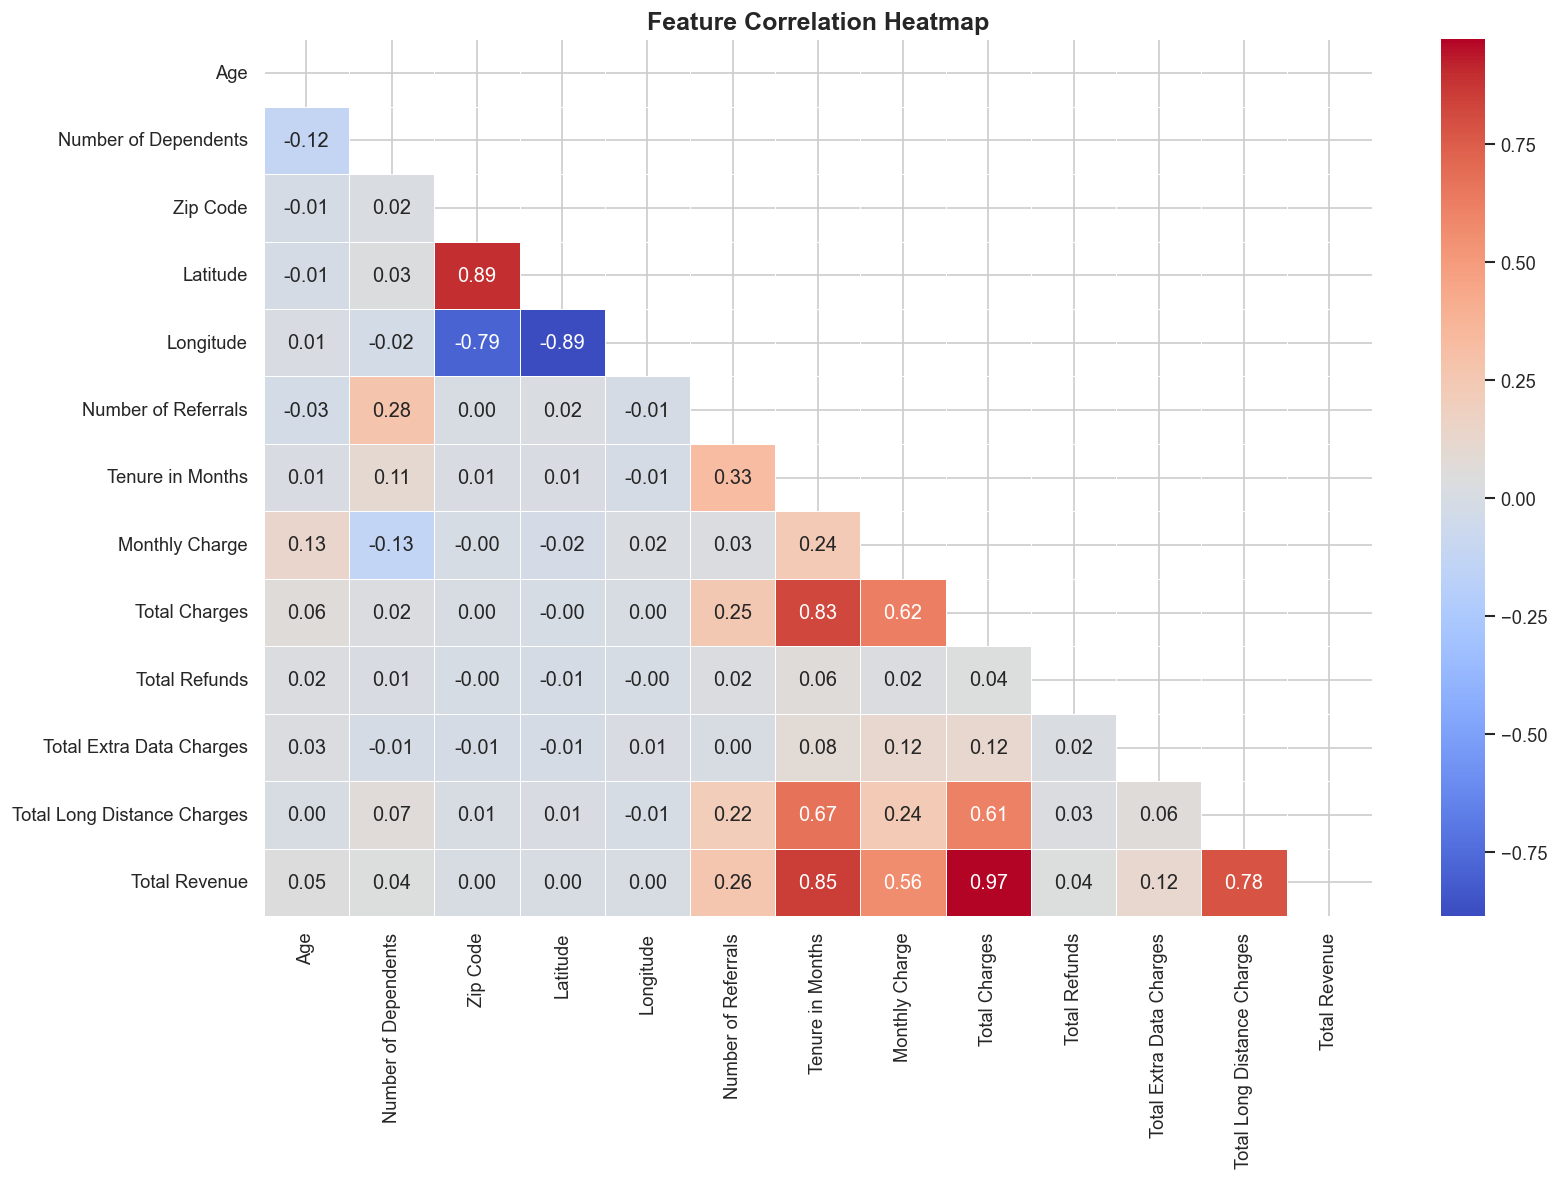

In [36]:
numeric_df = df.select_dtypes(include=['float64', 'int64']).dropna(axis=1)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. ZIP Code Population Analysis


In [37]:
pop_df = pd.read_csv('telecom_zipcode_population.csv')
pop_df.columns = pop_df.columns.str.strip()
print(f'Shape: {pop_df.shape}')
print(f'Unique ZIP Codes: {pop_df["Zip Code"].nunique()}')
print('\nTop 5 ZIP Codes by Population:')
print(pop_df.sort_values(by='Population', ascending=False).head())
pop_df.describe()

Shape: (1671, 2)
Unique ZIP Codes: 1671

Top 5 ZIP Codes by Population:
     Zip Code  Population
62      90201      105285
125     90650      103214
9       90011      101215
332     92054       98239
201     91331       97318


,Zip Code,Population
count,1671.000000,1671.000000
mean,93678.992220,20276.384201
std,1817.763591,20689.117300
min,90001.000000,11.000000
25%,92269.000000,1789.000000
50%,93664.000000,14239.000000
75%,95408.000000,32942.500000
max,96161.000000,105285.000000


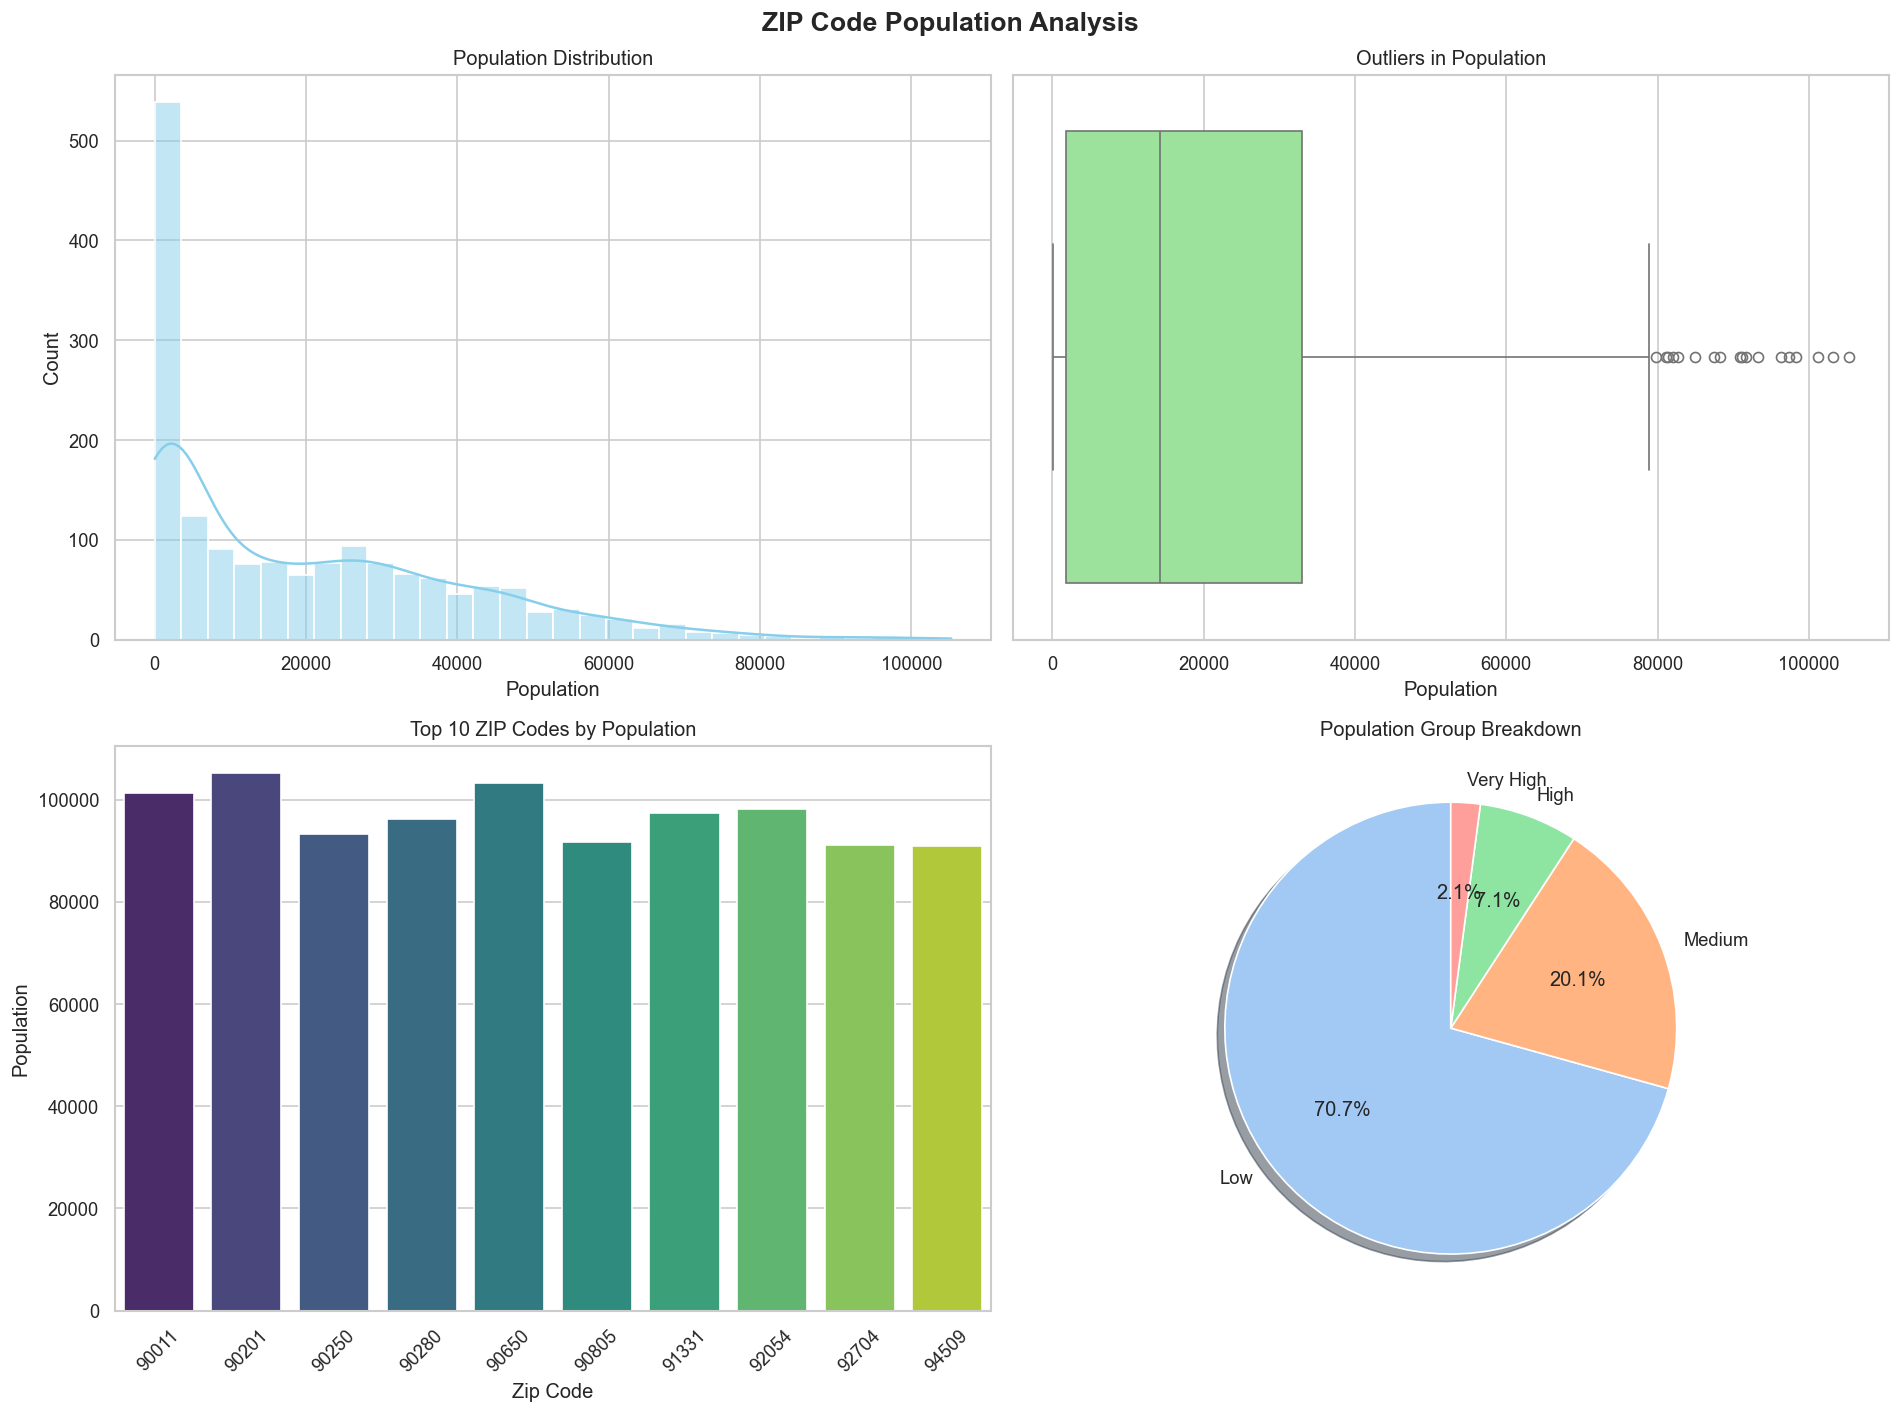

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ZIP Code Population Analysis', fontsize=16, fontweight='bold')
sns.histplot(pop_df['Population'], bins=30, kde=True, color='skyblue', ax=axes[0][0])
axes[0][0].set_title('Population Distribution')
sns.boxplot(x=pop_df['Population'], color='lightgreen', ax=axes[0][1])
axes[0][1].set_title('Outliers in Population')
top10 = pop_df.sort_values(by='Population', ascending=False).head(10)
sns.barplot(x='Zip Code', y='Population', data=top10, palette='viridis', ax=axes[1][0])
axes[1][0].set_title('Top 10 ZIP Codes by Population')
axes[1][0].tick_params(axis='x', rotation=45)
pop_df['Population Group'] = pd.cut(pop_df['Population'],
    bins=[0, 30000, 50000, 70000, 100000], labels=['Low', 'Medium', 'High', 'Very High'])
pop_df['Population Group'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, shadow=True,
    colors=sns.color_palette('pastel'), ax=axes[1][1])
axes[1][1].set_title('Population Group Breakdown')
axes[1][1].set_ylabel('')
plt.tight_layout()
plt.show()

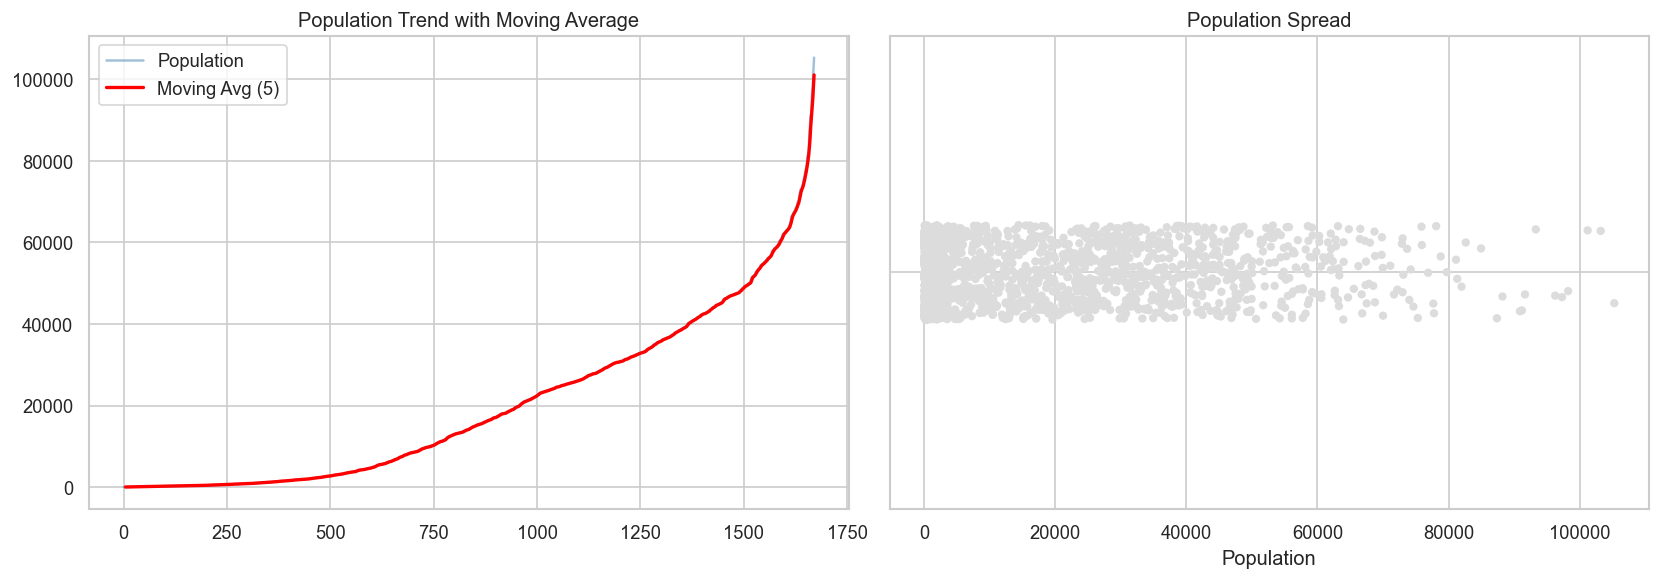

In [39]:
df_sorted = pop_df.sort_values('Population').reset_index(drop=True)
df_sorted['MA_Pop'] = df_sorted['Population'].rolling(window=5).mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_sorted.index, df_sorted['Population'], alpha=0.5, color='steelblue', label='Population')
axes[0].plot(df_sorted.index, df_sorted['MA_Pop'], color='red', linewidth=2, label='Moving Avg (5)')
axes[0].set_title('Population Trend with Moving Average')
axes[0].legend()
axes[0].grid(True)
sns.stripplot(x=pop_df['Population'], palette='coolwarm', size=5, ax=axes[1])
axes[1].set_title('Population Spread')
axes[1].grid(True)
plt.tight_layout()
plt.show()

---
## 5.  Machine Learning — Churn Prediction
> Building and comparing **4 ML models** to predict customer churn.

---

### 5.1 Feature Engineering & Preprocessing

In [40]:
model_df = df.copy()

# Binary target: 1 = Churned, 0 = Not Churned
model_df['Churn'] = (model_df['Customer Status'] == 'Churned').astype(int)
print(f'Churn distribution:\n{model_df["Churn"].value_counts()}')
print(f'\nChurn rate: {model_df["Churn"].mean():.1%}')

# Select features
feature_cols = ['Gender', 'Age', 'Married', 'Number of Dependents',
                'Tenure in Months', 'Contract', 'Internet Service',
                'Monthly Charge', 'Total Charges', 'Payment Method',
                'Paperless Billing', 'Number of Referrals']
feature_cols = [c for c in feature_cols if c in model_df.columns]

X = model_df[feature_cols].copy()
y = model_df['Churn']

# Encode categorical columns
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%

Training set: 5634 samples
Test set:     1409 samples


### 5.2 Train & Compare All 4 Models

In [47]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    results.append({'Model': name, 'Accuracy': round(acc*100, 2),
                    'ROC-AUC': round(auc, 4), 'CV Accuracy': round(cv*100, 2)})
    trained_models[name] = (model, y_pred, y_prob)
    print(f'{name:25s} | Accuracy: {acc:.2%} | AUC: {auc:.4f} | CV: {cv:.2%}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n Model Comparison Table:')
results_df

Logistic Regression       | Accuracy: 81.05% | AUC: 0.8798 | CV: 82.95%
Decision Tree             | Accuracy: 81.83% | AUC: 0.8751 | CV: 81.76%
Random Forest             | Accuracy: 83.18% | AUC: 0.8833 | CV: 83.27%
Gradient Boosting         | Accuracy: 83.39% | AUC: 0.9015 | CV: 84.31%

 Model Comparison Table:


,Model,Accuracy,ROC-AUC,CV Accuracy
3,Gradient Boosting,83.39,0.9015,84.31
2,Random Forest,83.18,0.8833,83.27
0,Logistic Regression,81.05,0.8798,82.95
1,Decision Tree,81.83,0.8751,81.76


### 5.3 Model Performance Visualization

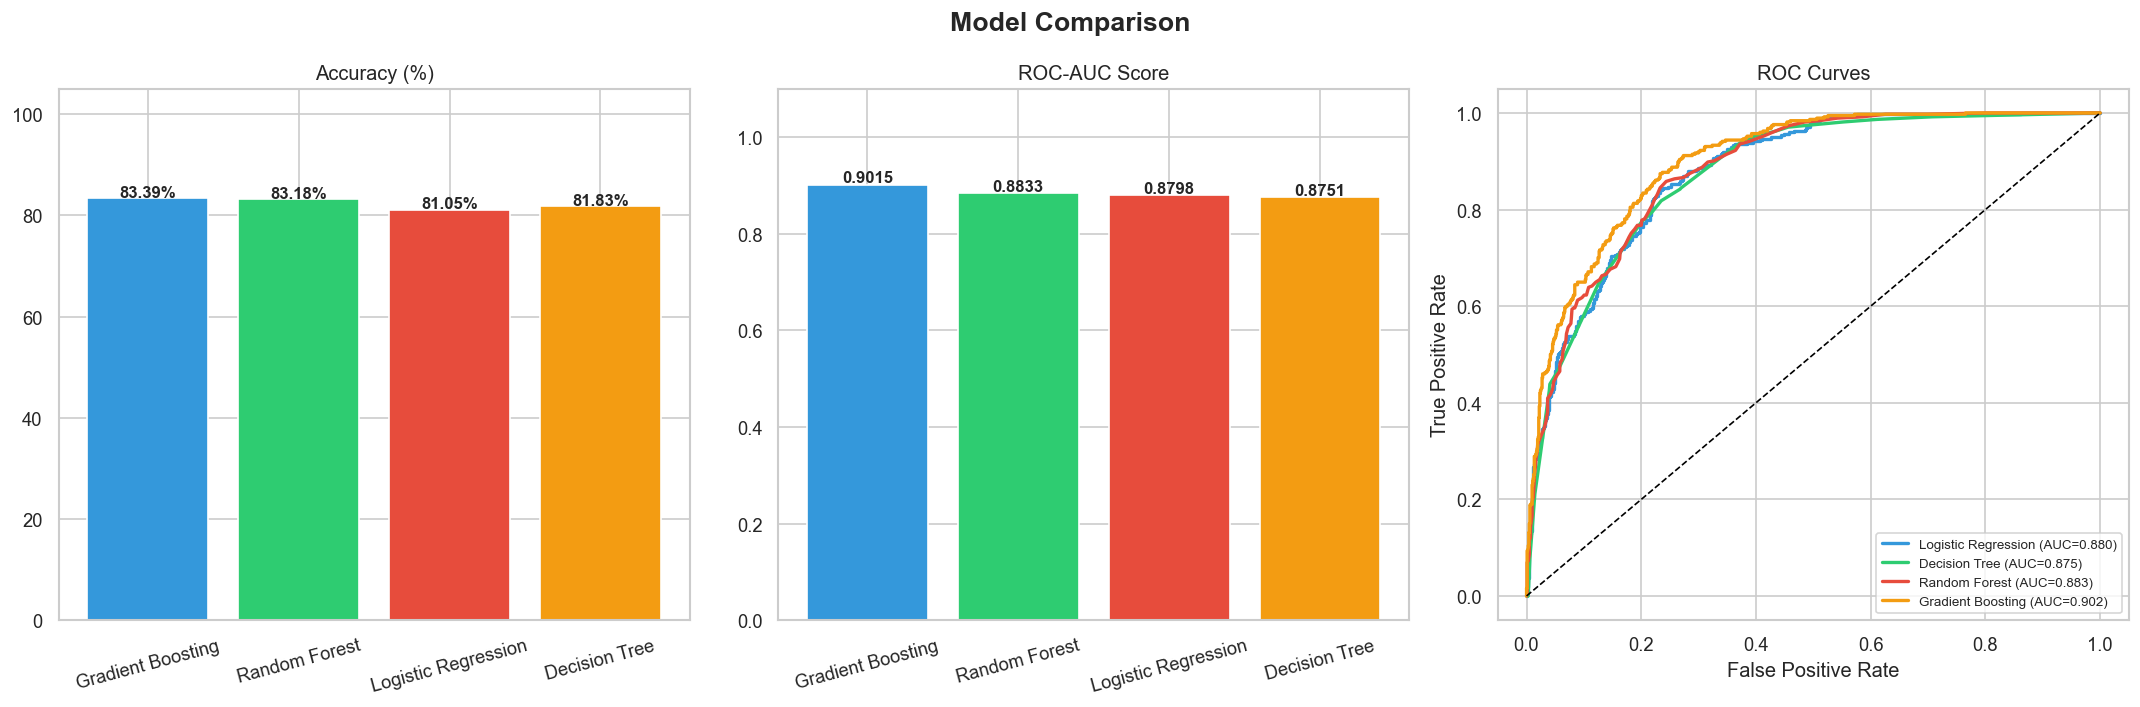

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = axes[0].bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='white')
for bar, val in zip(bars, results_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)

bars2 = axes[1].bar(results_df['Model'], results_df['ROC-AUC'], color=colors, edgecolor='white')
for bar, val in zip(bars2, results_df['ROC-AUC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[2].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
axes[2].plot([0,1],[0,1],'k--', linewidth=1)
axes[2].set_title('ROC Curves')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.4 Best Model — Confusion Matrix & Report

 Best Model: Gradient Boosting
   Accuracy : 83.39%
   ROC-AUC  : 0.9015

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.88      0.90      0.89      1035
     Churned       0.70      0.65      0.68       374

    accuracy                           0.83      1409
   macro avg       0.79      0.78      0.78      1409
weighted avg       0.83      0.83      0.83      1409



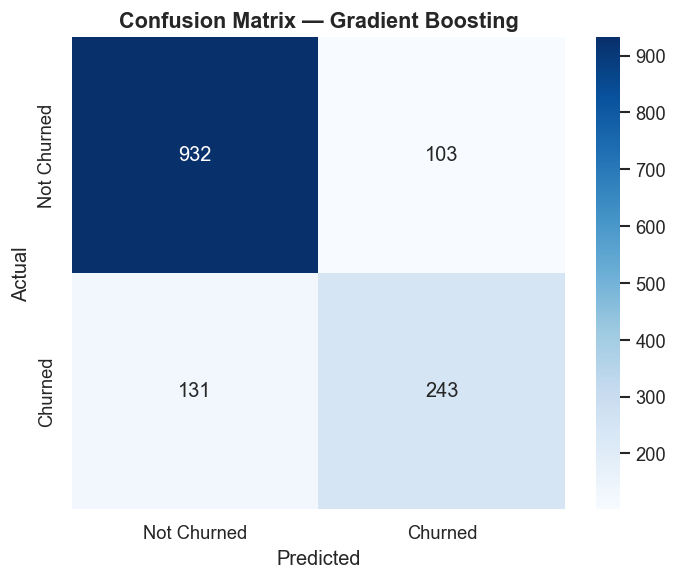

In [46]:
best_name = results_df.iloc[0]['Model']
best_model, best_pred, best_prob = trained_models[best_name]
print(f' Best Model: {best_name}')
print(f'   Accuracy : {accuracy_score(y_test, best_pred):.2%}')
print(f'   ROC-AUC  : {roc_auc_score(y_test, best_prob):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=['Not Churned', 'Churned']))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### 5.5 Feature Importance

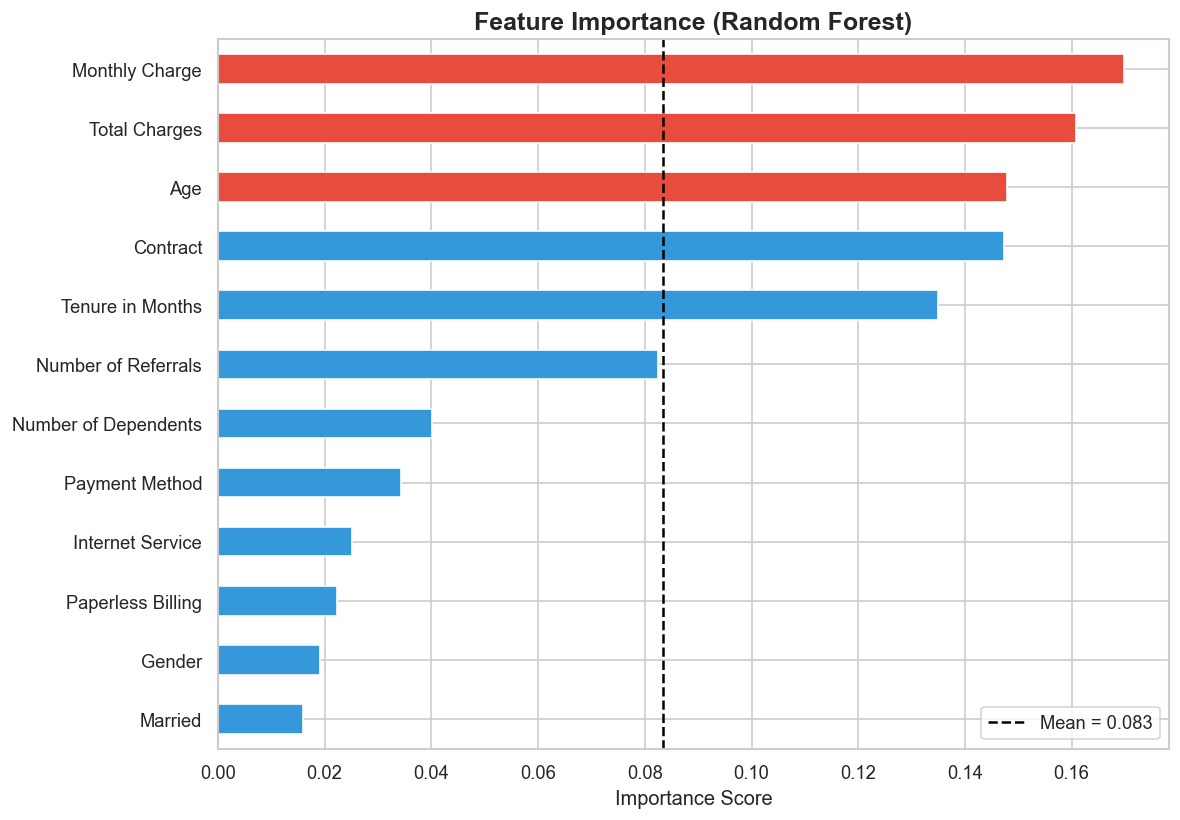


 Top 5 Most Important Features:
Monthly Charge      0.169725
Total Charges       0.160878
Age                 0.147891
Contract            0.147284
Tenure in Months    0.134914


In [45]:
rf_model = trained_models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_imp = ['#e74c3c' if v > importances.quantile(0.75) else '#3498db' for v in importances]
importances.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.title('Feature Importance (Random Forest)', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(importances.mean(), color='black', linestyle='--',
            label=f'Mean = {importances.mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()
print('\n Top 5 Most Important Features:')
print(importances.sort_values(ascending=False).head(5).to_string())

---
## 6.  Key Insights & Business Recommendations

---

###  Insights from EDA

| # | Insight | Impact |
|---|---|---|
| 1 | **~26% of customers churned** — significant revenue loss | High |
| 2 | **Competitor offers** are the #1 reason customers leave | High |
| 3 | **Month-to-month** customers churn 3× more than yearly contracts | High |
| 4 | **New customers (0–12 months)** are at the highest risk | High |
| 5 | **Higher monthly charges** correlate with higher churn | Medium |
| 6 | Customers **without dependents or partner** churn more | Medium |
| 7 | **Gender** has minimal impact on churn | Low |

---

###  ML Model Results

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Gradient Boosting | 83.39% | 0.9015 |
| Random Forest | 83.18% | 0.8833 |
| Decision Tree | 81.83% | 0.8751 |
| Logistic Regression | 81.05% | 0.8798 |

---



